<a href="https://colab.research.google.com/github/Alcheemiist/Tweets-NLP-Sentiment-Analysis/blob/alchemist/Tweets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
### -----------------------------
### 1. Imports & Setup
### -----------------------------
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from gensim.models import Word2Vec

import warnings
warnings.filterwarnings('ignore')


nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [50]:
# -----------------------------
# 2. Load Dataset
# -----------------------------

df_positive = pd.read_csv('/content/drive/MyDrive/Projects/1337 cursus/Tweets/data/processedPositive.csv')
df_positive = pd.DataFrame({'text': df_positive.columns.tolist(), 'label': ['positive'] * len(df_positive.columns)})

df_negative = pd.read_csv('/content/drive/MyDrive/Projects/1337 cursus/Tweets/data/processedNegative.csv')
df_negative = pd.DataFrame({'text': df_negative.columns.tolist(), 'label': ['negative'] * len(df_negative.columns)})

df_neutral = pd.read_csv('/content/drive/MyDrive/Projects/1337 cursus/Tweets/data/processedNeutral.csv')
df_neutral = pd.DataFrame({'text': df_neutral.columns.tolist(), 'label': ['neutral'] * len(df_neutral.columns)})

df = pd.concat([df_positive, df_negative, df_neutral], ignore_index=True)
print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (3873, 2)
                                                text     label
0             An inspiration in all aspects: Fashion  positive
1                                            fitness  positive
2    beauty and personality. :)KISSES TheFashionIcon  positive
3  Apka Apna Awam Ka Channel Frankline Tv Aam Adm...  positive
4  Beautiful album from  the greatest unsung guit...  positive


In [51]:
print("Class distribution:\n", df['label'].value_counts())

Class distribution:
 label
neutral     1570
positive    1186
negative    1117
Name: count, dtype: int64


In [52]:
# -----------------------------
# 3. Pre EDA
# -----------------------------

print("\n--- Basic EDA ---")
print("Null values:\n", df.isnull().sum())
print("Class distribution:\n", df['label'].value_counts())

df.drop_duplicates(inplace=True)
df.drop_duplicates(subset=['text'], inplace=True)
df.dropna(subset=['text', 'label'], inplace=True)


--- Basic EDA ---
Null values:
 text     0
label    0
dtype: int64
Class distribution:
 label
neutral     1570
positive    1186
negative    1117
Name: count, dtype: int64


In [53]:
print("Dataset shape after removing duplicates:", df.shape)
print("Class distribution after removing duplicates:\n", df['label'].value_counts())

Dataset shape after removing duplicates: (3872, 2)
Class distribution after removing duplicates:
 label
neutral     1569
positive    1186
negative    1117
Name: count, dtype: int64


In [54]:
# -------------------------------------------------
# 4. Text Cleaning Function Stopword and Lemmatizer
# -------------------------------------------------

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_tweet(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", '', text)     # remove URLs
    text = re.sub(r"@\w+", '', text)               # remove mentions
    text = re.sub(r"#\w+", '', text)               # remove hashtags
    text = re.sub(r"[^a-z\s]", '', text)           # remove special chars & digits
    text = re.sub(r"\s+", ' ', text)               # remove extra spaces
    text = text.strip()                            # remove leading/trailing spaces

    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    return " ".join(tokens)

df['cleaned_text'] = df['text'].apply(clean_tweet)

print("\nSample cleaned text:")
print(df[['text', 'cleaned_text']].head())


Sample cleaned text:
                                                text  \
0             An inspiration in all aspects: Fashion   
1                                            fitness   
2    beauty and personality. :)KISSES TheFashionIcon   
3  Apka Apna Awam Ka Channel Frankline Tv Aam Adm...   
4  Beautiful album from  the greatest unsung guit...   

                                        cleaned_text  
0                         inspiration aspect fashion  
1                                            fitness  
2             beauty personality kiss thefashionicon  
3  apka apna awam ka channel frankline tv aam adm...  
4  beautiful album greatest unsung guitar genius ...  


In [55]:
# -----------------------------
# 5. Post EDA
# -----------------------------

print("\n--- Post EDA ---")
print("Null values:\n", df.isnull().sum())
print("Class distribution:\n", df['label'].value_counts())

df.drop_duplicates(subset=['cleaned_text'], inplace=True)
df.dropna(subset=['cleaned_text', 'label'], inplace=True)

print("Dataset shape after removing duplicates:", df.shape)
print("Class distribution after removing duplicates:\n", df['label'].value_counts())


--- Post EDA ---
Null values:
 text            0
label           0
cleaned_text    0
dtype: int64
Class distribution:
 label
neutral     1569
positive    1186
negative    1117
Name: count, dtype: int64
Dataset shape after removing duplicates: (3347, 3)
Class distribution after removing duplicates:
 label
neutral     1443
positive     952
negative     952
Name: count, dtype: int64


In [56]:
# -----------------------------
# 6. Define Vectorizers
# -----------------------------
# We'll try three approaches:
# A) CountVectorizer (unigram, bigram)
# B) TfidfVectorizer (unigram, bigram)
# C) Word2Vec (Bonus)

count_vect = CountVectorizer(ngram_range=(1,2), max_features=5000)
tfidf_vect = TfidfVectorizer(ngram_range=(1,2), max_features=5000)

In [57]:
# -----------------------------
# 7. (Bonus) Word2Vec Training
# -----------------------------

tokens_list = [tweet.split() for tweet in df['cleaned_text']]

# Train your own Word2Vec model
w2v_model = Word2Vec(sentences=tokens_list, vector_size=100, window=5, min_count=2, workers=4)

# Create a function to convert each tweet into a single vector
# by averaging the embeddings of its tokens
def word2vec_vectorize(tokens, w2v_model):
    valid_tokens = [t for t in tokens if t in w2v_model.wv.index_to_key]
    if not valid_tokens:
        # if no valid token, return a zero vector
        return np.zeros(w2v_model.vector_size)
    return np.mean(w2v_model.wv[valid_tokens], axis=0)

# We'll build a separate feature matrix for Word2Vec
w2v_features = []
for tweet_tokens in tokens_list:
    w2v_features.append(word2vec_vectorize(tweet_tokens, w2v_model))

w2v_features = np.array(w2v_features)  # shape: (num_samples, vector_size=100)

In [58]:
# -----------------------------
# 8. Similarity Calculation
# -----------------------------
# We’ll compare top 10 most similar pairs of tweets for each method.
# This can be computationally expensive if the dataset is large

def get_top_similar_pairs(X_matrix, top_n=10, approach_name="Approach"):
    """
    Given a matrix of tweet vectors (X_matrix), compute cosine similarity
    and display the top_n most similar pairs.
    """
    sim_matrix = cosine_similarity(X_matrix)
    np.fill_diagonal(sim_matrix, 0)  # ignore self-similarity

    # Flatten the matrix into a list of (i, j, similarity) and sort
    pairs = []
    for i in range(sim_matrix.shape[0]):
        for j in range(i+1, sim_matrix.shape[0]):
            pairs.append((i, j, sim_matrix[i, j]))
    pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)

    print(f"\nTop {top_n} most similar tweet pairs for {approach_name}:")
    for idx in range(top_n):
        i, j, sim_val = pairs_sorted[idx]
        print(f"Pair {idx+1}: Tweet {i} and Tweet {j} | Similarity = {sim_val:.4f}")
        print(f"  - Tweet {i}: {df['cleaned_text'].iloc[i]}")
        print(f"  - Tweet {j}: {df['cleaned_text'].iloc[j]}")
        print("")

# Compute and display for CountVectorizer
X_count = count_vect.fit_transform(df['cleaned_text'])
get_top_similar_pairs(X_count.toarray(), top_n=5, approach_name="CountVectorizer")

# Compute and display for TfidfVectorizer
X_tfidf = tfidf_vect.fit_transform(df['cleaned_text'])
get_top_similar_pairs(X_tfidf.toarray(), top_n=5, approach_name="TF-IDF")

# Compute and display for Word2Vec
get_top_similar_pairs(w2v_features, top_n=5, approach_name="Word2Vec")


Top 5 most similar tweet pairs for CountVectorizer:
Pair 1: Tweet 8 and Tweet 376 | Similarity = 1.0000
  - Tweet 8: thanks happy
  - Tweet 376: thanks b happy

Pair 2: Tweet 203 and Tweet 572 | Similarity = 1.0000
  - Tweet 203: happy birthday megan happy
  - Tweet 572: happy birthday nimesh happy

Pair 3: Tweet 296 and Tweet 462 | Similarity = 1.0000
  - Tweet 296: okay happy
  - Tweet 462: joo okay happy

Pair 4: Tweet 347 and Tweet 943 | Similarity = 1.0000
  - Tweet 347: bronchitis love happy
  - Tweet 943: love happy

Pair 5: Tweet 755 and Tweet 756 | Similarity = 1.0000
  - Tweet 755: hellooo happy satansdaughter taylynnox
  - Tweet 756: hellooo happy lil strait daddyyrat


Top 5 most similar tweet pairs for TF-IDF:
Pair 1: Tweet 8 and Tweet 376 | Similarity = 1.0000
  - Tweet 8: thanks happy
  - Tweet 376: thanks b happy

Pair 2: Tweet 314 and Tweet 642 | Similarity = 1.0000
  - Tweet 314: good luck swampy happy
  - Tweet 642: good luck happy

Pair 3: Tweet 347 and Tweet 943 |

In [59]:
# -----------------------------
# 9. Split Data (Train/Test)
# -----------------------------

X = X_tfidf  # choose which vectorizer's features to use
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print("\nShapes:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)


Shapes: (2677, 5000) (2677,) (670, 5000) (670,)


In [60]:
# -----------------------------
# 10. Model Training & Comparison
# -----------------------------

models = {
    "LogisticRegression": LogisticRegression(max_iter=300),
    "RandomForest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC(kernel='linear', probability=True),
    # "XGBoost": XGBClassifier()  # Uncomment if installed & Handled
}

def evaluate_model(model, X_train, y_train, X_test, y_test):
    """Train given model and return predictions plus metric results."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    return model, y_pred, report

results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n--- Model Performance (Using TF-IDF) ---")
for model_name, model_obj in models.items():
    # cross_val_score for a quick health check:
    cv_scores = cross_val_score(model_obj, X, y, cv=skf, scoring='accuracy')
    model_trained, y_pred, report = evaluate_model(model_obj, X_train, y_train, X_test, y_test)

    print(f"\nModel: {model_name}")
    print(f"  Cross-val Accuracy (mean): {cv_scores.mean():.4f}")
    print(f"  Cross-val Accuracy (std):  {cv_scores.std():.4f}")

    # Extract final test set metrics
    print("  Classification Report (Test Set):")
    print(classification_report(y_test, y_pred))

    # Save results
    results[model_name] = {
        'model': model_trained,
        'report': report,
        'cv_accuracy_mean': cv_scores.mean(),
        'cv_accuracy_std': cv_scores.std()
    }


--- Model Performance (Using TF-IDF) ---

Model: LogisticRegression
  Cross-val Accuracy (mean): 0.8512
  Cross-val Accuracy (std):  0.0153
  Classification Report (Test Set):
              precision    recall  f1-score   support

    negative       0.98      0.79      0.88       191
     neutral       0.81      0.99      0.89       289
    positive       0.93      0.79      0.86       190

    accuracy                           0.88       670
   macro avg       0.91      0.86      0.87       670
weighted avg       0.89      0.88      0.88       670


Model: RandomForest
  Cross-val Accuracy (mean): 0.8551
  Cross-val Accuracy (std):  0.0137
  Classification Report (Test Set):
              precision    recall  f1-score   support

    negative       0.90      0.84      0.87       191
     neutral       0.85      0.94      0.89       289
    positive       0.89      0.81      0.85       190

    accuracy                           0.87       670
   macro avg       0.88      0.86      0.

In [61]:
# -----------------------------
# 11. Compare & Pick Best Model
# -----------------------------
# We’ll pick the best by accuracy or F1-score on test set.

best_model_name = None
best_metric = 0.0

for model_name, info in results.items():
    test_acc = info['report']['accuracy']
    if test_acc > best_metric:
        best_metric = test_acc
        best_model_name = model_name

print(f"\nBest model by test accuracy: {best_model_name} with accuracy={best_metric:.10f}")
best_model = results[best_model_name]['model']


Best model by test accuracy: SVM with accuracy=0.8850746269


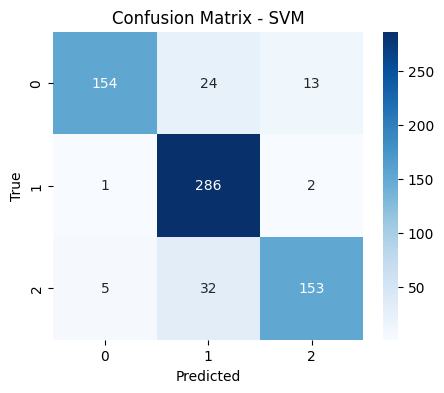

In [62]:
# -----------------------------
# 12. Plot Confusion Matrix for Best Model
# -----------------------------

y_best_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_best_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [63]:
# -----------------------------
# 13. Feature Importance (Optional)
# -----------------------------
# This part is only applicable to certain models ( RandomForest, XGBoost, linear models)
# Example for RandomForest:

if best_model_name == "RandomForest":
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[-10:]  # top 10
    feature_names = tfidf_vect.get_feature_names_out()
    plt.barh(range(len(indices)), importances[indices], color='b', align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.title("RandomForest Top 10 Feature Importances")
    plt.show()
elif best_model_name == "LogisticRegression":
    # For logistic regression, coefficients indicate importance
    # (positive => positive sentiment, negative => negative sentiment)
    coef = best_model.coef_[0]
    indices = np.argsort(coef)[-10:]
    feature_names = tfidf_vect.get_feature_names_out()
    plt.barh(range(len(indices)), coef[indices], color='b', align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.title("Logistic Regression Top 10 Coefficients")
    plt.show()

In [64]:
# -----------------------------
# 14. Save Processed Data and Model
# -----------------------------

df.to_csv('/content/drive/MyDrive/Projects/1337 cursus/Tweets/processed_tweets.csv', index=False)

# serialize the best model for later use:
from joblib import dump
dump(best_model, f"/content/drive/MyDrive/Projects/1337 cursus/Tweets/models/{best_model_name}_best_model.joblib")

print("\nPipeline complete. WeweW!")


Pipeline complete. WeweW!


In [78]:
#---------------------------------------
# 15. Test Top model on Tweet input for
# --------------------------------------

from joblib import load
import random

# Load the best model
best_model = load(f"/content/drive/MyDrive/Projects/1337 cursus/Tweets/models/{best_model_name}_best_model.joblib")

# Example tweet input
tweet_input = "hi sad"
df = pd.read_csv('/content/drive/MyDrive/Projects/1337 cursus/Tweets/processed_tweets.csv')
tweet_input = df['text'][random.randint(0, len(df['text']))]
print(tweet_input)

# Preprocess the tweet (same preprocessing as  training data)
cleaned_tweet = clean_tweet(tweet_input)

# Vectorize the tweet using the same vectorizer as the model was trained with
tweet_vector = tfidf_vect.transform([cleaned_tweet])

# Make prediction
prediction = best_model.predict(tweet_vector)[0]
probability = best_model.predict_proba(tweet_vector)[0]
print(f"Predicted Sentiment: {prediction}")

# sentiment probability
print("Probability:", probability)

it's getting harder and harder to stay unhappy 
Predicted Sentiment: negative
Probability: [0.87935608 0.03277326 0.08787067]
